In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("laptop_data.csv")

In [ ]:
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080
...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200


In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(dtype=int)
trn=ohe.fit_transform(df[['Company']]).toarray()

In [ ]:
trn_df=pd.DataFrame(trn)

In [ ]:
trn_df.iloc[0,:].to_list()

[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
df.ScreenResolution

,ScreenResolution
0,IPS Panel Retina Display 2560x1600
1,1440x900
2,Full HD 1920x1080
3,IPS Panel Retina Display 2880x1800
4,IPS Panel Retina Display 2560x1600
...,...
1298,IPS Panel Full HD / Touchscreen 1920x1080
1299,IPS Panel Quad HD+ / Touchscreen 3200x1800
1300,1366x768
1301,1366x768


In [ ]:
def convertor(a):
  l=a.split()
  pixel=l[-1]
  touch= 1 if 'Touchscreen' in l else 0
  pixel=pixel.split("x")
  pixel=list(map(lambda x: int(x) , pixel))
  pixel.append(touch)
  return pixel

In [ ]:
convertor(df.ScreenResolution[0] )

[2560, 1600, 0]

In [ ]:
new=df.ScreenResolution.apply(convertor)

In [ ]:
width=new.apply(lambda x: x[0])
height=new.apply(lambda x: x[1])
touch=new.apply(lambda x : x[2])

In [ ]:
df['width']=width

In [ ]:
df['height']=height

In [ ]:
df['tp']=df['width']*df['height']

In [ ]:
df['Touchscreen']=touch

In [ ]:
df.tp

,tp
0,4096000
1,1296000
2,2073600
3,5184000
4,4096000
...,...
1298,2073600
1299,5760000
1300,1049088
1301,1049088


In [ ]:
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,width,height,tp,Touchscreen
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560,1600,4096000,0
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440,900,1296000,0
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920,1080,2073600,0
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880,1800,5184000,0
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560,1600,4096000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,1920,1080,2073600,1
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16GB,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,3200,1800,5760000,1
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,1366,768,1049088,0
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6GB,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,1366,768,1049088,0


In [ ]:
df.Ram=df['Ram'].apply(lambda x : int(x.replace('GB','')) )

In [ ]:
df

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,width,height,tp,Touchscreen
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832,2560,1600,4096000,0
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232,1440,900,1296000,0
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000,1920,1080,2073600,0
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360,2880,1800,5184000,0
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080,2560,1600,4096000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8kg,33992.6400,1920,1080,2073600,1
1299,1299,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3kg,79866.7200,3200,1800,5760000,1
1300,1300,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5kg,12201.1200,1366,768,1049088,0
1301,1301,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19kg,40705.9200,1366,768,1049088,0


In [ ]:
df['Weight']= df['Weight'].apply(lambda x : x[:-2])

# **ips**

In [ ]:
df['Ips']=df['ScreenResolution'].apply(lambda x : 1 if 'IPS' in x else 0)

In [ ]:
df.drop(columns=['ScreenResolution'],inplace=True)

In [ ]:
( df.Cpu.unique().tolist())


['Intel Core i5 2.3GHz',
 'Intel Core i5 1.8GHz',
 'Intel Core i5 7200U 2.5GHz',
 'Intel Core i7 2.7GHz',
 'Intel Core i5 3.1GHz',
 'AMD A9-Series 9420 3GHz',
 'Intel Core i7 2.2GHz',
 'Intel Core i7 8550U 1.8GHz',
 'Intel Core i5 8250U 1.6GHz',
 'Intel Core i3 6006U 2GHz',
 'Intel Core i7 2.8GHz',
 'Intel Core M m3 1.2GHz',
 'Intel Core i7 7500U 2.7GHz',
 'Intel Core i7 2.9GHz',
 'Intel Core i3 7100U 2.4GHz',
 'Intel Atom x5-Z8350 1.44GHz',
 'Intel Core i5 7300HQ 2.5GHz',
 'AMD E-Series E2-9000e 1.5GHz',
 'Intel Core i5 1.6GHz',
 'Intel Core i7 8650U 1.9GHz',
 'Intel Atom x5-Z8300 1.44GHz',
 'AMD E-Series E2-6110 1.5GHz',
 'AMD A6-Series 9220 2.5GHz',
 'Intel Celeron Dual Core N3350 1.1GHz',
 'Intel Core i3 7130U 2.7GHz',
 'Intel Core i7 7700HQ 2.8GHz',
 'Intel Core i5 2.0GHz',
 'AMD Ryzen 1700 3GHz',
 'Intel Pentium Quad Core N4200 1.1GHz',
 'Intel Atom x5-Z8550 1.44GHz',
 'Intel Celeron Dual Core N3060 1.6GHz',
 'Intel Core i5 1.3GHz',
 'AMD FX 9830P 3GHz',
 'Intel Core i7 7560U 2.4

In [ ]:
def conv_cpu(text):
  text=text.split()[:3]
  text=" ".join(text)
  if text=='Intel Core i7' or text=='Intel Core i5' or text=='Intel Core i3':
    return text
  elif("AMD" in text ):
    return "AMD"
  else :
      return "other cpu"

In [ ]:
conv_cpu(df.Cpu[30])

'other cpu'

In [ ]:
df['Cpu brand']=df['Cpu'].apply(conv_cpu)

In [ ]:
df[['Cpu','Cpu brand']]

,Cpu,Cpu brand
0,Intel Core i5 2.3GHz,Intel Core i5
1,Intel Core i5 1.8GHz,Intel Core i5
2,Intel Core i5 7200U 2.5GHz,Intel Core i5
3,Intel Core i7 2.7GHz,Intel Core i7
4,Intel Core i5 3.1GHz,Intel Core i5
...,...,...
1298,Intel Core i7 6500U 2.5GHz,Intel Core i7
1299,Intel Core i7 6500U 2.5GHz,Intel Core i7
1300,Intel Celeron Dual Core N3050 1.6GHz,other cpu
1301,Intel Core i7 6500U 2.5GHz,Intel Core i7


<Axes: xlabel='Cpu brand'>

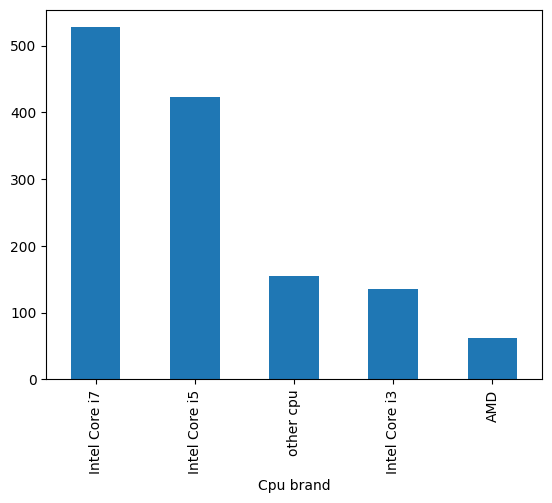

In [ ]:
df['Cpu brand'].value_counts().plot(kind='bar')

<BarContainer object of 1303 artists>

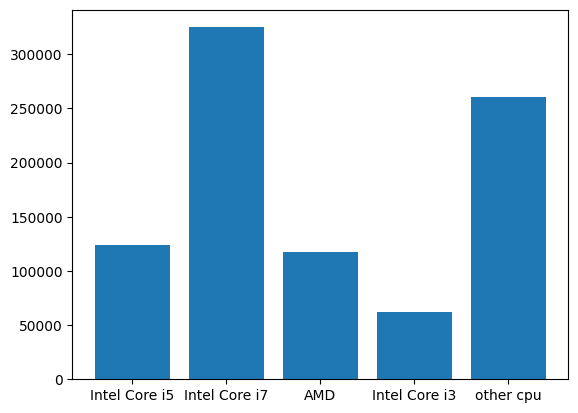

In [ ]:
import matplotlib.pyplot as plt

plt.bar(df['Cpu brand'],df['Price'])

In [ ]:
df

,Unnamed: 0,Company,TypeName,Inches,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,width,height,tp,Touchscreen,Ips,Cpu brand
0,0,Apple,Ultrabook,13.3,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600,4096000,0,1,Intel Core i5
1,1,Apple,Ultrabook,13.3,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900,1296000,0,0,Intel Core i5
2,2,HP,Notebook,15.6,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080,2073600,0,0,Intel Core i5
3,3,Apple,Ultrabook,15.4,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800,5184000,0,1,Intel Core i7
4,4,Apple,Ultrabook,13.3,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560,1600,4096000,0,1,Intel Core i5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,Lenovo,2 in 1 Convertible,14.0,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.8,33992.6400,1920,1080,2073600,1,1,Intel Core i7
1299,1299,Lenovo,2 in 1 Convertible,13.3,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.3,79866.7200,3200,1800,5760000,1,1,Intel Core i7
1300,1300,Lenovo,Notebook,14.0,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.5,12201.1200,1366,768,1049088,0,0,other cpu
1301,1301,HP,Notebook,15.6,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,1366,768,1049088,0,0,Intel Core i7


In [ ]:
df.drop(columns='Cpu' ,inplace=True)

<Axes: xlabel='Ram', ylabel='Price'>

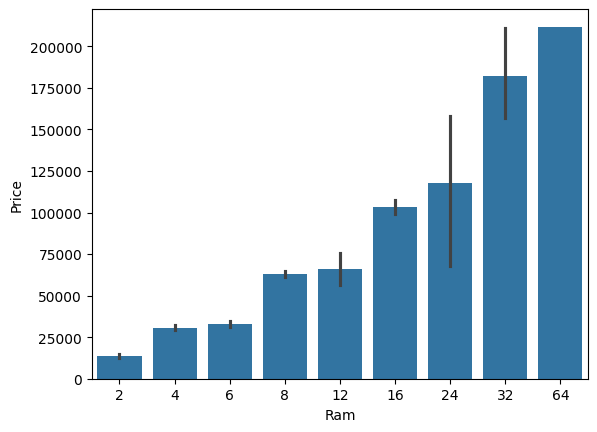

In [ ]:
import seaborn as sns
sns.barplot(x=df['Ram'],y=df['Price'])

In [ ]:
df['Memory'].value_counts()

,count
Memory,
256GB SSD,412
1TB HDD,223
500GB HDD,132
512GB SSD,118
128GB SSD + 1TB HDD,94
128GB SSD,76
256GB SSD + 1TB HDD,73
32GB Flash Storage,38
2TB HDD,16


In [ ]:
df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
df["Memory"] = df["Memory"].str.replace('GB', '')
df["Memory"] = df["Memory"].str.replace('TB', '000')
new = df["Memory"].str.split("+", n = 1, expand = True)

df["first"]= new[0]
df["first"]=df["first"].str.strip()

df["second"]= new[1]

df["Layer1HDD"] = df["first"].apply(lambda x: 1 if "HDD" in str(x) else 0)
df["Layer1SSD"] = df["first"].apply(lambda x: 1 if "SSD" in str(x) else 0)
df["Layer1Hybrid"] = df["first"].apply(lambda x: 1 if "Hybrid" in str(x) else 0)
df["Layer1Flash_Storage"] = df["first"].apply(lambda x: 1 if "Flash Storage" in str(x) else 0)

df['first'] = df['first'].str.extract('(\\d+)').fillna(0).astype(int)

df["second"].fillna("0", inplace = True)

df["Layer2HDD"] = df["second"].apply(lambda x: 1 if "HDD" in str(x) else 0)
df["Layer2SSD"] = df["second"].apply(lambda x: 1 if "SSD" in str(x) else 0)
df["Layer2Hybrid"] = df["second"].apply(lambda x: 1 if "Hybrid" in str(x) else 0)
df["Layer2Flash_Storage"] = df["second"].apply(lambda x: 1 if "Flash Storage" in str(x) else 0)

df['second'] = df['second'].str.extract('(\\d+)').fillna(0).astype(int)

df["HDD"]=(df["first"]*df["Layer1HDD"]+df["second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash_Storage"]+df["second"]*df["Layer2Flash_Storage"])

df.drop(columns=['first', 'second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash_Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash_Storage'],inplace=True)


<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_970/3060535665.py:1: SyntaxWarning: invalid escape sequence '\.'
  df['Memory'] = df['Memory'].astype(str).replace('\.0', '', regex=True)
/tmp/ipykernel_970/3060535665.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["second"].fillna("0", inplace = True)


In [ ]:
df.iloc[1247:1257,:]

,Unnamed: 0,Company,TypeName,Inches,Ram,Memory,Gpu,OpSys,Weight,Price,width,height,tp,Touchscreen,Ips,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
1247,1247,Asus,Gaming,15.6,16,256 SSD + 1000 HDD,Nvidia GeForce GTX 1070,Windows 10,2.34,123876.0000,1920,1080,2073600,0,1,Intel Core i7,1000,256,0,0
1248,1248,Lenovo,Notebook,15.6,8,256 SSD,Intel HD Graphics 620,No OS,2.3,30529.4400,1920,1080,2073600,0,1,Intel Core i5,0,256,0,0
1249,1249,Dell,2 in 1 Convertible,13.3,8,256 SSD,Intel HD Graphics 615,Windows 10,1.24,96596.6400,3200,1800,5760000,1,0,Intel Core i5,0,256,0,0
1250,1250,Dell,Notebook,15.6,4,500 HDD,Intel HD Graphics,Linux,2.2,17262.7200,1366,768,1049088,0,0,other cpu,500,0,0,0
1251,1251,HP,Notebook,15.6,4,500 HDD,AMD Radeon R4 Graphics,Windows 10,1.86,21258.7200,1366,768,1049088,0,0,AMD,500,0,0,0
1252,1252,Lenovo,Notebook,15.6,6,128 SSD,Nvidia GeForce 920MX,Windows 10,2.4,30316.3200,1920,1080,2073600,0,0,Intel Core i3,0,128,0,0
1253,1253,Lenovo,Notebook,14.0,8,256 SSD,Intel HD Graphics 520,Windows 10,1.9,57116.1600,1920,1080,2073600,0,1,Intel Core i5,0,256,0,0
1254,1254,Dell,Notebook,15.6,4,500 HDD,Intel HD Graphics,Windows 10,2.2,23655.7872,1366,768,1049088,0,0,other cpu,500,0,0,0
1255,1255,Asus,Notebook,15.6,4,1000 HDD,Intel HD Graphics 500,Windows 10,2,18061.9200,1366,768,1049088,0,0,other cpu,1000,0,0,0
1256,1256,Asus,Gaming,17.3,16,128 SSD + 1000 HDD,Nvidia GeForce GTX 970M,Windows 10,4.0,101232.0000,1920,1080,2073600,0,1,Intel Core i7,1000,128,0,0


In [ ]:
df.drop(columns=['Memory','Unnamed: 0'],inplace=True)

In [ ]:
df

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,width,height,tp,Touchscreen,Ips,Cpu brand,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600,4096000,0,1,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900,1296000,0,0,Intel Core i5,0,0,0,128
2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080,2073600,0,0,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800,5184000,0,1,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560,1600,4096000,0,1,Intel Core i5,0,256,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,Intel HD Graphics 520,Windows 10,1.8,33992.6400,1920,1080,2073600,1,1,Intel Core i7,0,128,0,0
1299,Lenovo,2 in 1 Convertible,13.3,16,Intel HD Graphics 520,Windows 10,1.3,79866.7200,3200,1800,5760000,1,1,Intel Core i7,0,512,0,0
1300,Lenovo,Notebook,14.0,2,Intel HD Graphics,Windows 10,1.5,12201.1200,1366,768,1049088,0,0,other cpu,0,0,0,64
1301,HP,Notebook,15.6,6,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,1366,768,1049088,0,0,Intel Core i7,1000,0,0,0


### Calculating Pixels Per Inch (PPI)

To calculate Pixels Per Inch (PPI), we use the following formula:

`PPI = √(width² + height²) / Inches`

Where:
- `width` is the screen width in pixels.
- `height` is the screen height in pixels.
- `Inches` is the diagonal size of the screen in inches.

In [ ]:
import numpy as np
df['ppi'] = (((df['width']**2) + (df['height']**2))**0.5) / df['Inches']
display(df.head())

,Company,TypeName,Inches,Ram,Gpu,OpSys,Weight,Price,width,height,tp,Touchscreen,Ips,Cpu brand,HDD,SSD,Hybrid,Flash_Storage,ppi
0,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,2560,1600,4096000,0,1,Intel Core i5,0,128,0,0,226.983005
1,Apple,Ultrabook,13.3,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,1440,900,1296000,0,0,Intel Core i5,0,0,0,128,127.677940
2,HP,Notebook,15.6,8,Intel HD Graphics 620,No OS,1.86,30636.0000,1920,1080,2073600,0,0,Intel Core i5,0,256,0,0,141.211998
3,Apple,Ultrabook,15.4,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,2880,1800,5184000,0,1,Intel Core i7,0,512,0,0,220.534624
4,Apple,Ultrabook,13.3,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,2560,1600,4096000,0,1,Intel Core i5,0,256,0,0,226.983005


In [ ]:
df['Weight'] = df['Weight'].astype(float)

In [ ]:
correlation_with_price = df.select_dtypes(include=np.number).corr()['Price']
display(correlation_with_price)

,Price
Inches,0.068197
Ram,0.743007
Weight,0.210370
Price,1.000000
width,0.556529
height,0.552809
tp,0.515486
Touchscreen,0.191226
Ips,0.252208
HDD,-0.096441


In [ ]:
df.drop(columns=['Flash_Storage','Hybrid'],inplace=True)

In [ ]:
df['Gpu'].value_counts().index.to_list()

['Intel HD Graphics 620',
 'Intel HD Graphics 520',
 'Intel UHD Graphics 620',
 'Nvidia GeForce GTX 1050',
 'Nvidia GeForce GTX 1060',
 'Nvidia GeForce 940MX',
 'AMD Radeon 530',
 'Intel HD Graphics 500',
 'Intel HD Graphics 400',
 'Nvidia GeForce GTX 1070',
 'Intel HD Graphics',
 'Nvidia GeForce GTX 1050 Ti',
 'AMD Radeon R5 M430',
 'Nvidia GeForce 930MX',
 'AMD Radeon 520',
 'Nvidia GeForce MX150',
 'Intel HD Graphics 515',
 'Intel HD Graphics 615',
 'AMD Radeon R7 M445',
 'Nvidia GeForce GTX 960M',
 'Nvidia GeForce 920MX',
 'Intel HD Graphics 505',
 'AMD Radeon R5',
 'Nvidia GeForce GTX 980M',
 'Nvidia Quadro M1200',
 'Intel HD Graphics 405',
 'Intel Iris Plus Graphics 640',
 'AMD Radeon R5 M420',
 'AMD Radeon R5 M330',
 'Nvidia GeForce GTX 950M',
 'Nvidia GeForce 920M',
 'Nvidia GeForce 930M',
 'Nvidia GeForce GTX 1080',
 'Nvidia GeForce MX130',
 'AMD Radeon R4 Graphics',
 'Nvidia Quadro M620',
 'AMD Radeon R7 M440',
 'Nvidia GeForce GTX 970M',
 'Nvidia GeForce GT 940MX',
 'AMD Rad

In [ ]:
def Gpu_convertor(text):
  if 'intel' in text.lower():
    return 'intel'
  elif 'nvidia' in text.lower():
    return "nvidia"
  elif 'amd' in text.lower() :
    return 'amd'
  else:
    return 'others'

In [ ]:
df['Gpu Brand']=df.Gpu.apply(Gpu_convertor)

In [ ]:
df[['Gpu Brand']].value_counts()

,count
Gpu Brand,
intel,722
nvidia,400
amd,180
others,1


<Axes: xlabel='Gpu Brand', ylabel='Price'>

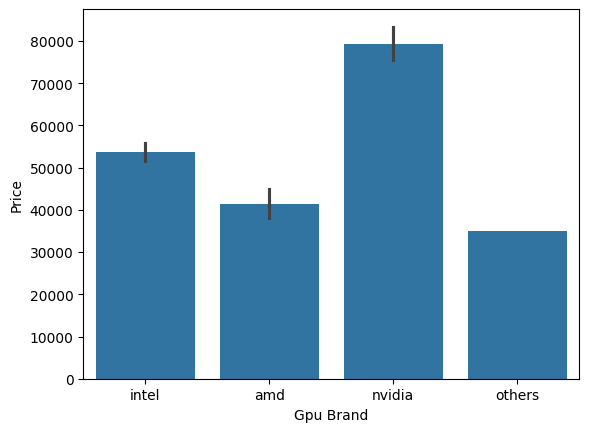

In [ ]:
sns.barplot(x=df['Gpu Brand'],y=df['Price'])

In [ ]:
df.drop(columns=['Gpu'],inplace=True)

In [ ]:
df['OpSys'].value_counts()

,count
OpSys,
Windows 10,1072
No OS,66
Linux,62
Windows 7,45
Chrome OS,27
macOS,13
Mac OS X,8
Windows 10 S,8
Android,2


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'macOS'),
  Text(1, 0, 'No OS'),
  Text(2, 0, 'Windows 10'),
  Text(3, 0, 'Mac OS X'),
  Text(4, 0, 'Linux'),
  Text(5, 0, 'Android'),
  Text(6, 0, 'Windows 10 S'),
  Text(7, 0, 'Chrome OS'),
  Text(8, 0, 'Windows 7')])

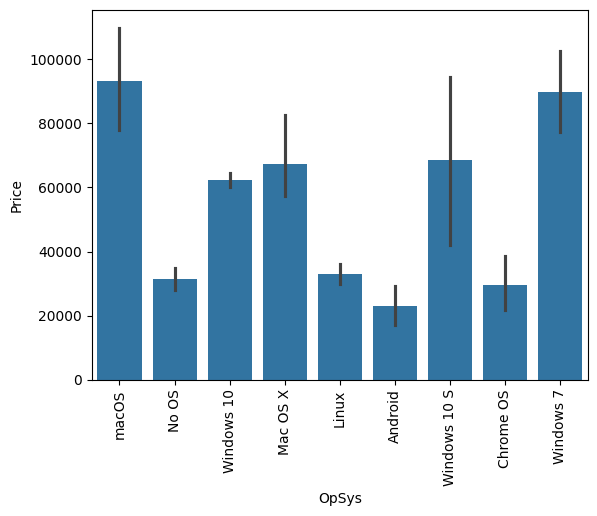

In [ ]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation="vertical")

In [ ]:
def os_convertor(text):
  if 'windows' in text.lower() :
      return "Windows"
  elif 'mac' in text.lower() :
    return "MacOs"
  else :
    return "others/linux/Android"

In [ ]:
df['Os Brand']=df.OpSys.apply(os_convertor)

In [ ]:
df[['OpSys','Os Brand']]

,OpSys,Os Brand
0,macOS,MacOs
1,macOS,MacOs
2,No OS,others/linux/Android
3,macOS,MacOs
4,macOS,MacOs
...,...,...
1298,Windows 10,Windows
1299,Windows 10,Windows
1300,Windows 10,Windows
1301,Windows 10,Windows


<Axes: xlabel='Os Brand', ylabel='Price'>

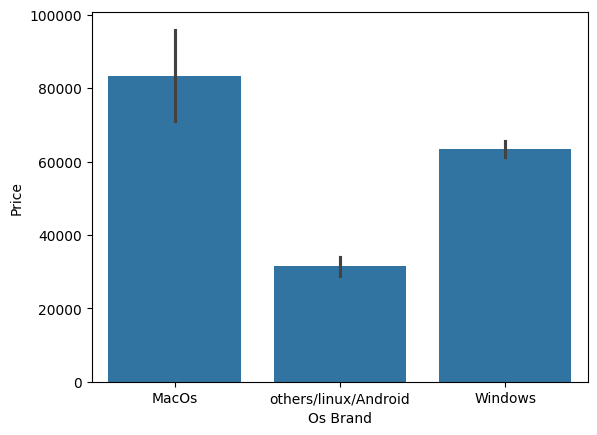

In [ ]:
sns.barplot(x=df['Os Brand'],y=df['Price'])

In [ ]:
df.drop(columns=['OpSys'],inplace=True)

/tmp/ipykernel_970/1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

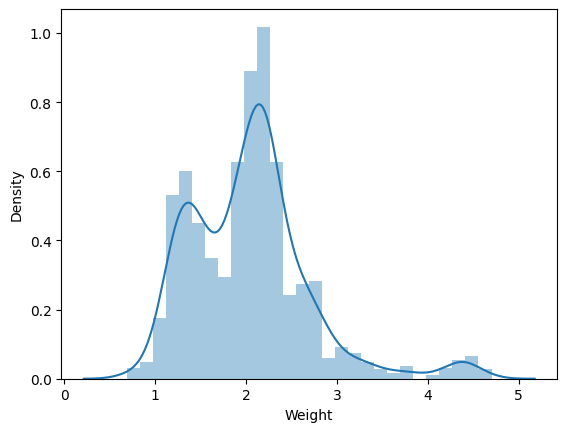

In [ ]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Price'>

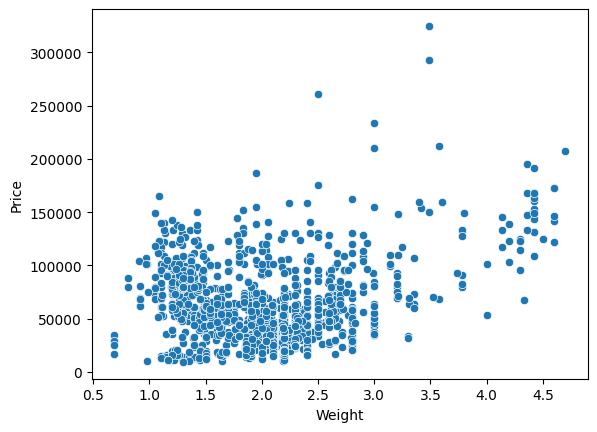

In [ ]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

In [ ]:
df['Price'].corr(df['Weight'])

np.float64(0.21036979891687177)

In [ ]:
df

,Company,TypeName,Inches,Ram,Weight,Price,width,height,tp,Touchscreen,Ips,Cpu brand,HDD,SSD,ppi,Gpu Brand,Os Brand
0,Apple,Ultrabook,13.3,8,1.37,71378.6832,2560,1600,4096000,0,1,Intel Core i5,0,128,226.983005,intel,MacOs
1,Apple,Ultrabook,13.3,8,1.34,47895.5232,1440,900,1296000,0,0,Intel Core i5,0,0,127.677940,intel,MacOs
2,HP,Notebook,15.6,8,1.86,30636.0000,1920,1080,2073600,0,0,Intel Core i5,0,256,141.211998,intel,others/linux/Android
3,Apple,Ultrabook,15.4,16,1.83,135195.3360,2880,1800,5184000,0,1,Intel Core i7,0,512,220.534624,amd,MacOs
4,Apple,Ultrabook,13.3,8,1.37,96095.8080,2560,1600,4096000,0,1,Intel Core i5,0,256,226.983005,intel,MacOs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,Lenovo,2 in 1 Convertible,14.0,4,1.80,33992.6400,1920,1080,2073600,1,1,Intel Core i7,0,128,157.350512,intel,Windows
1299,Lenovo,2 in 1 Convertible,13.3,16,1.30,79866.7200,3200,1800,5760000,1,1,Intel Core i7,0,512,276.053530,intel,Windows
1300,Lenovo,Notebook,14.0,2,1.50,12201.1200,1366,768,1049088,0,0,other cpu,0,0,111.935204,intel,Windows
1301,HP,Notebook,15.6,6,2.19,40705.9200,1366,768,1049088,0,0,Intel Core i7,1000,0,100.454670,amd,Windows


<Axes: >

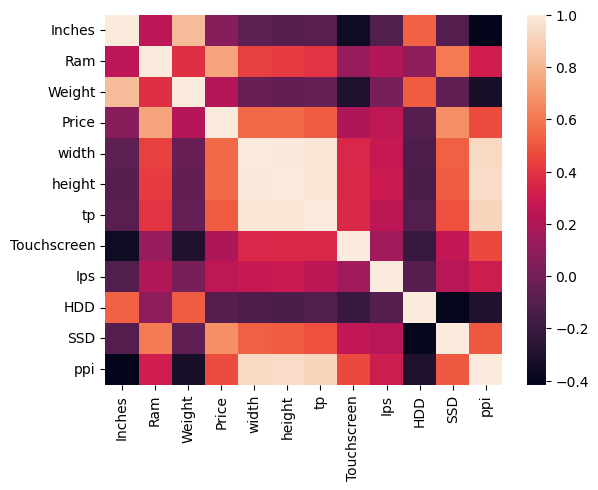

In [ ]:
sns.heatmap(df.select_dtypes(include=np.number).corr())

<Axes: >

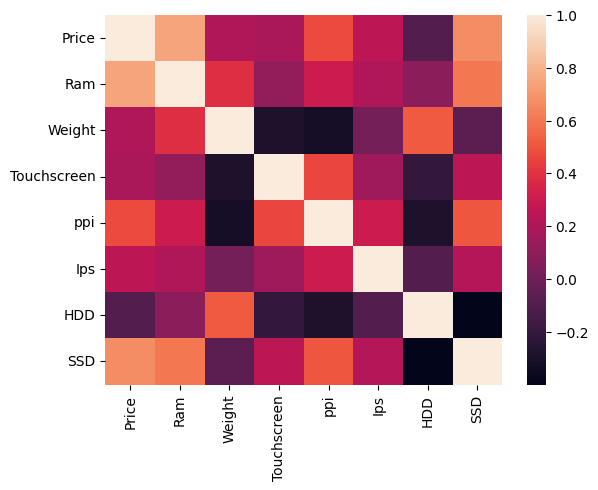

In [ ]:
df_selected = df[['Price', 'Ram', 'Weight', 'Touchscreen', 'ppi', 'Ips', 'HDD', 'SSD']]
sns.heatmap(df_selected.corr())

/tmp/ipykernel_970/3556049916.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price']))


<Axes: xlabel='Price', ylabel='Density'>

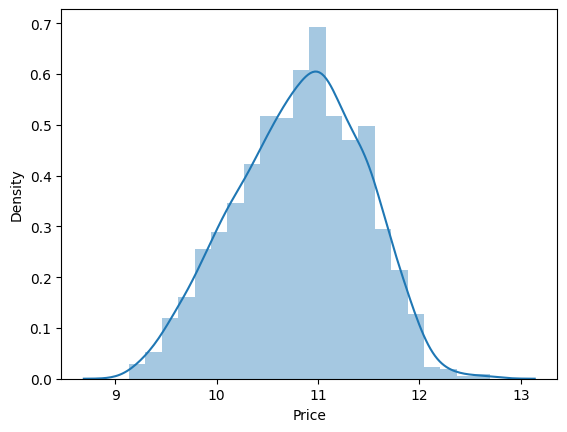

In [ ]:
sns.distplot(np.log(df['Price']))

In [ ]:
numerical_df = df.select_dtypes(include=np.number)
display(numerical_df.head())


,Inches,Ram,Weight,Price,width,height,tp,Touchscreen,Ips,HDD,SSD,ppi
0,13.3,8,1.37,71378.6832,2560,1600,4096000,0,1,0,128,226.983005
1,13.3,8,1.34,47895.5232,1440,900,1296000,0,0,0,0,127.677940
2,15.6,8,1.86,30636.0000,1920,1080,2073600,0,0,0,256,141.211998
3,15.4,16,1.83,135195.3360,2880,1800,5184000,0,1,0,512,220.534624
4,13.3,8,1.37,96095.8080,2560,1600,4096000,0,1,0,256,226.983005


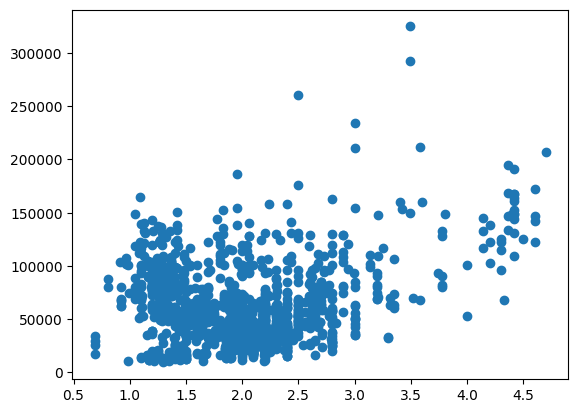

In [ ]:
plt.scatter(df['Weight'],df['Price'])

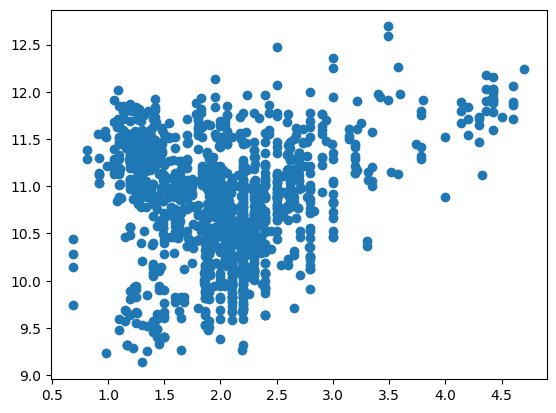

In [ ]:
plt.scatter(df['Weight'],np.log(df['Price']))

In [ ]:
df=df.drop(columns=['width','height','tp','Inches'])

In [ ]:
df.head()

,Company,TypeName,Ram,Weight,Price,Touchscreen,Ips,Cpu brand,HDD,SSD,ppi,Gpu Brand,Os Brand
0,Apple,Ultrabook,8,1.37,71378.6832,0,1,Intel Core i5,0,128,226.983005,intel,MacOs
1,Apple,Ultrabook,8,1.34,47895.5232,0,0,Intel Core i5,0,0,127.677940,intel,MacOs
2,HP,Notebook,8,1.86,30636.0000,0,0,Intel Core i5,0,256,141.211998,intel,others/linux/Android
3,Apple,Ultrabook,16,1.83,135195.3360,0,1,Intel Core i7,0,512,220.534624,amd,MacOs
4,Apple,Ultrabook,8,1.37,96095.8080,0,1,Intel Core i5,0,256,226.983005,intel,MacOs


In [ ]:
x=df.drop(columns=['Price'])
y=np.log(df['Price'])

In [ ]:
x.head()

,Company,TypeName,Ram,Weight,Touchscreen,Ips,Cpu brand,HDD,SSD,ppi,Gpu Brand,Os Brand
0,Apple,Ultrabook,8,1.37,0,1,Intel Core i5,0,128,226.983005,intel,MacOs
1,Apple,Ultrabook,8,1.34,0,0,Intel Core i5,0,0,127.677940,intel,MacOs
2,HP,Notebook,8,1.86,0,0,Intel Core i5,0,256,141.211998,intel,others/linux/Android
3,Apple,Ultrabook,16,1.83,0,1,Intel Core i7,0,512,220.534624,amd,MacOs
4,Apple,Ultrabook,8,1.37,0,1,Intel Core i5,0,256,226.983005,intel,MacOs


# **modeling**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.15,random_state=2)

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score,mean_absolute_error

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor,ExtraTreesRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

#LinearRegression





In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )
step2= LinearRegression()
pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])
pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)
print("R2 score :",r2_score(y_test,y_pred))
print("MAE score :",mean_absolute_error(y_test,y_pred))

R2 score : 0.8244080790204555
MAE score : 0.20979730662632076


# **Ridge Regression**

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )

step2 = Ridge(alpha=10)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8226046929336819
MAE 0.21023897133827668


# **Lasso Regression**

In [ ]:

step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )
step2 = Lasso(alpha=0.001)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.823617812428641
MAE 0.21102059782813787


# **Knn**

In [ ]:

step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11]) ]
    ,remainder='passthrough' )

step2 = KNeighborsRegressor(n_neighbors=3)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8321787903167426
MAE 0.19367724626349841


# **Decision Tree**

In [ ]:

step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )
step2 = DecisionTreeRegressor(max_depth=8)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8380742194326545
MAE 0.18824259772390575


# **Extra Trees**

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )

step2 = ExtraTreesRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15,
                              bootstrap=True)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.88746211413266
MAE 0.16623948676855352


# **SVM**

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )
step2 = SVR(kernel='rbf',C=10000,epsilon=0.1)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8538621507885852
MAE 0.19017983153876233


# **Random Forest**

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )

step2 = RandomForestRegressor(n_estimators=100,
                              random_state=3,
                              max_samples=0.5,
                              max_features=0.75,
                              max_depth=15)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8848844990931515
MAE 0.16228718936930422


# **Gradient Boosting**

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )

step2 = GradientBoostingRegressor(n_estimators=500)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8892555130933034
MAE 0.1613141384057856


XGBoost Regressor

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf',OneHotEncoder(sparse_output=False,drop='first'),[0,1,6,10,11] ) ]
    ,remainder='passthrough' )

step2 = XGBRegressor(n_estimators=45,max_depth=5,learning_rate=0.5)

pipe = Pipeline([
    ('step1',step1),
    ('step2',step2)
])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('R2 score',r2_score(y_test,y_pred))
print('MAE',mean_absolute_error(y_test,y_pred))

R2 score 0.8947283493897134
MAE 0.15632016967968498


# overall best models :
*   Random Forest
*             R2 score 0.8900604362145471
*             MAE 0.1579573297210532
*   XGBoost Regressor
*             R2 score 0.8914270782063727
*             MAE 0.15561564643134126
*   ExtraTreesRegressor
*            R2 score 0.8893641291863563
*            MAE 0.16464374007349933



# ***ENSEMBLE TECHNIQUES***

In [ ]:
from sklearn.ensemble import VotingRegressor,StackingRegressor

VOTING REGRESSOR

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,6,10,11])
], remainder='passthrough')


rf = RandomForestRegressor(
    n_estimators=350,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15
)

xgb = XGBRegressor(
    n_estimators=25,
    learning_rate=0.3,
    max_depth=5
)

et = ExtraTreesRegressor(
    n_estimators=350,
    random_state=3,
    max_features=0.75
)


step2 = VotingRegressor(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('et', et)
    ],
    weights=[2,3,1]
)


pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])


pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print('R2 score', r2_score(y_test, y_pred))
print('MAE', mean_absolute_error(y_test, y_pred))


R2 score 0.8915512225390717
MAE 0.1557106582986378


*   Stacking Regressor

In [ ]:
step1 = ColumnTransformer(transformers=[
    ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'), [0,1,6,10,11])
], remainder='passthrough')


rf = RandomForestRegressor(
    n_estimators=350,
    random_state=3,
    max_samples=0.5,
    max_features=0.75,
    max_depth=15
)

xgb = XGBRegressor(
    n_estimators=25,
    learning_rate=0.3,
    max_depth=5
)

et = ExtraTreesRegressor(
    n_estimators=350,
    random_state=3,
    max_features=0.75
)


step2 = StackingRegressor(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('et', et)
    ],
    final_estimator=LinearRegression()
)


pipe = Pipeline([
    ('step1', step1),
    ('step2', step2)
])


pipe.fit(x_train, y_train)

y_pred = pipe.predict(x_test)

print('R2 score', r2_score(y_test, y_pred))
print('MAE', mean_absolute_error(y_test, y_pred))

R2 score 0.8938061643298876
MAE 0.1538834852265332


# Voting regressor vs stacking regressor
* stacking regressor clearly outperforms other models also

# **Downloading DataFrame and Pipeline**

In [ ]:
import joblib

# Save model with compression
joblib.dump(pipe, "pipe.joblib", compress=3)
joblib.dump(df,'df.joblib')

['df.joblib']

In [ ]:
input=df.drop(columns=['Price']).iloc[0,:].to_frame().T
pipe.predict(input)

array([11.23595047])

In [ ]:
query_data = {
    'Company': [company],
    'TypeName': [type],
    'Inches': [inches],
    'Ram': [ram],
    'Weight': [weight],
    'Touchscreen': [touchscreen],
    'Ips': [ips],
    'Cpu brand': [cpu],
    'HDD': [hdd],
    'SSD': [ssd],
    'ppi': [ppi],
    'Gpu Brand': [gpu],
    'Os Brand': [os]
}
query_df = pd.DataFrame(query_data)
st.title("The predicted price of this configuration is " + str(int(np.exp(pipe.predict(query_df)[0]))))

NameError: name 'company' is not defined

In [ ]:
company = df['Company'].iloc[0]
type = df['TypeName'].iloc[0]

ram = df['Ram'].iloc[0]
weight = df['Weight'].iloc[0]
touchscreen = df['Touchscreen'].iloc[0]
ips = df['Ips'].iloc[0]
cpu = df['Cpu brand'].iloc[0]
hdd = df['HDD'].iloc[0]
ssd = df['SSD'].iloc[0]
ppi = df['ppi'].iloc[0]
gpu = df['Gpu Brand'].iloc[0]
os = df['Os Brand'].iloc[0]

In [ ]:
query_data = {
    'Company': [company],
    'TypeName': [type],
    'Ram': [ram],
    'Weight': [weight],
    'Touchscreen': [touchscreen],
    'Ips': [ips],
    'Cpu brand': [cpu],
    'HDD': [hdd],
    'SSD': [ssd],
    'ppi': [ppi],
    'Gpu Brand': [gpu],
    'Os Brand': [os]
}
query_df = pd.DataFrame(query_data)
print("The predicted price of this configuration is " + str(int(np.exp(pipe.predict(query_df)[0]))))

The predicted price of this configuration is 75807
